## Prerequisites

In [ ]:
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/1. Data Preprocessing/1. LLM Data Pre-processing.ipynb"
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/2. Attention Mechanisms/2. Self-Attention.ipynb"
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/2. Attention Mechanisms/3. Causal Attention.ipynb"
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/2. Attention Mechanisms/4. Multi-Head Attention.ipynb"
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/3. LLM Architecture/1. GPT model from scratch.ipynb"
%run "C:/Users/ishaan phaye/Desktop/VS Code/A DL course/LLM/3. LLM Architecture/2. Evaluating LLMs.ipynb"

import torch
import torch.nn as nn

## **ENTIRE TRAINING LOOP FOR THE LLM**

In [2]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            # --- FIX: Move batch data to the target device (GPU or CPU) ---
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            # -------------------------------------------------------------
            
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen

Step 1: Initialize lists to track losses and tokens seen

Step 2: Start the main training loop

Step 3: Reset loss gradients from previous batch iteration

Step 4: Calculate loss gradients

Step 5: Update model weights using loss gradients

Step 6: Optional evaluation step

Step 7: Print a sample text after each epoch

In [3]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

The evaluate_model function calculates the loss over the training and validation set while ensuring the model is in evaluation mode with gradient tracking and dropout disabled when calculating the loss over the training and validation sets

In [4]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

The generate_and_print_sample function is a convenience function that we use to track whether the model improves during the training.

In particular, the generate_and_print_sample function takes a text snippet (start_context) as input, converts it into token IDs, and feeds it to the LLM to generate a text sample using the generate_text_simple function we used earlier

Let's see this all in action by training a GPTModel instance for 10 epochs using an AdamW optimizer and the train_model_simple function we defined earlier.

In [5]:
# import time
# import torch

# # 1. Define the device first
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # 2. Check if CUDA is available and being used
# if str(device) == "cpu" or not torch.cuda.is_available():
#     print("Notice: CUDA GPU is not available or CPU was assigned. Skipping training loop to protect performance. Continuing notebook execution...")
#     # Initialize empty variables so subsequent cells don't throw NameErrors
#     train_losses, val_losses, tokens_seen = [], [], []
# else:
#     print(f"GPU detected ({torch.cuda.get_device_name(0)}). Starting training loop...")
    
#     start_time = time.time()

#     torch.manual_seed(123)
#     model = GPTModel(GPT_CONFIG_124M)
#     model.to(device)
#     optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

#     num_epochs = 10
#     train_losses, val_losses, tokens_seen = train_model_simple(
#         model, train_loader, val_loader, optimizer, device,
#         num_epochs=num_epochs, eval_freq=5, eval_iter=5,
#         start_context="Every effort moves you", tokenizer=tokenizer
#     )

#     end_time = time.time()
#     execution_time_minutes = (end_time - start_time) / 60
#     print(f"Training completed in {execution_time_minutes:.2f} minutes.")

#### Saving the metrics needed for plotting

In [6]:
# # Bundle your metrics into a dictionary
# metrics = {
#     "train_losses": train_losses,
#     "val_losses": val_losses,
#     "tokens_seen": tokens_seen,
# }

# # Save them to a lightweight metrics file
# torch.save(metrics, "training_metrics.pth")
# print("Training metrics saved successfully!")

#### Loading them back

In [7]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the saved metrics file
metrics = torch.load("training_metrics.pth")

# Assign them back to your variables
train_losses = metrics["train_losses"]
val_losses = metrics["val_losses"]
tokens_seen = metrics["tokens_seen"]

print("Training metrics loaded successfully! Ready to plot.")

Training metrics loaded successfully! Ready to plot.


C:\Temp\ipykernel_1244\2029574425.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  metrics = torch.load("training_metrics.pth")


In [8]:
# checkpoint = torch.load("model_and_optimizer.pth")
# model = GPTModel(GPT_CONFIG_124M)
# model.load_state_dict(checkpoint["model_state_dict"])
# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
# optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
# model.train();

As we can see, based on the results printed during the training, the training loss improves drastically, starting with a value of 9.781 and converging to 0.391.

The language skills of the model have improved quite a lot. In the beginning, the model is only able to append commas to the start context ("Every effort moves you,,,,,,,,,,,,") or repeat the word "and".

At the end of the training, it can generate grammatically correct text.

Similar to the training set loss, we can see that the validation loss starts high (9.856) and decreases during the training.

However, it never becomes as small as the training set loss and remains at 6.372 after the 10th epoch.

Let's create a simple plot that shows the training and validation set losses side by side

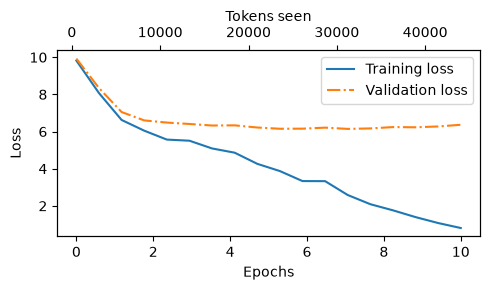

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

num_epochs = 10
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

Both the training and validation losses start to improve for the first epoch. However, the losses start to diverge past the second epoch.

This divergence and the fact that the validation loss is much larger than the training loss indicate that the model is overfitting to the training data.

We can confirm that the model memorizes the training data verbatim by searching for the generated text snippets, such as "quite insensible to the irony" in the "The Verdict" text file.

This memorization is expected since we are working with a very, very small training dataset and training the model for multiple epochs.

Usually, it's common to train a model on a much, much larger dataset for only one epoch.

## Testing on a custom input

In [10]:
# 1. Define your new starting sentence
start_context = "Hello, world! I am"

# 2. Encode the text into token IDs using your tokenizer
encoded = tokenizer.encode(start_context)
print(f"encoded text: {encoded}")

# 3. Convert to a PyTorch tensor, add a batch dimension (shape: [1, num_tokens]), and move to your device
encoded_tensor = torch.tensor(encoded).unsqueeze(0).to(device)

# 4. Put model in evaluation mode
model.eval()

# Make sure your tensor is on the same device as the model
encoded_tensor = encoded_tensor.to(device)

# 5. Generate new tokens (e.g., generate 50 new tokens)
out_tokens = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=50,
    context_size=GPT_CONFIG_124M["context_length"]
)

# 6. Decode the resulting token IDs back into readable text
decoded_text = tokenizer.decode(out_tokens.squeeze(0).tolist())

print("\n--- Generated Output ---")
print(decoded_text)

encoded text: [15496, 11, 995, 0, 314, 716]

--- Generated Output ---
Hello, world! I ammington anal sequential anus698 Jin MLS stained circumcision TT remember gard ACTIONSussedOND Land Engelenes phonesLasbleyOGR Requirements RL sacred ensuingBrandonskin asshole spaghetti}} ResurrectionEdge Moroc Gujarat red robe acoustic guaranteeingidden iPad spaces Griffpo Shaharr initiate batteredverse Snyder


# **DECODING STRATEGIES TO CONTROL RANDOMNESS**

First, we briefly revisit the generate_text_simple function from the previous chapter that we used inside the generate_and_print_sample earlier in this chapter.

Then, we will cover two techniques, temperature scaling, and top-k sampling, to improve this function.

We begin by transferring the model back from the GPU to the CPU since inference with a relatively small model does not require a GPU. 

Also, after training, we put the model into evaluation model to turn off random components such as dropout:

In [11]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

Next, we plug the GPTModel instance (model) into the generate_text_simple function, which uses the LLM to generate one token at a time:

In [12]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren Mortgage TT remember gard ACTIONSussedOND Land Engeleddedemate breaths proxies GalaxyForm


## **DECODING STRATEGY 1: TEMPERATURE SCALING**
Previously, inside the generate_text_simple function, we always sampled the token with the highest probability as the next token using torch.argmax, also known as greedy decoding.

To generate text with more variety, we can replace the argmax with a function that samples from a probability distribution (here, the probability scores the LLM generates for each vocabulary entry at each token generation step).

To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the next-token generation process using a very small vocabulary for illustration purposes:

In [13]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

Next, assume the LLM is given the start context "every effort moves you" and generates the following next-token logits:

In [14]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

As discussed in the previous chapter, inside the generate_text_simple, we convert the logits into probabilities via the softmax function and obtain the token ID corresponding the generated token via the argmax function, which we can then map back into text via the inverse vocabulary:

In [15]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


To implement a probabilistic sampling process, we can now replace the argmax with the multinomial function in PyTorch:

In [16]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

toward


The printed output is "forward" just like before. What happened? The multinomial function samples the next token proportional to its probability score.

In other words, "forward" is still the most likely token and will be selected by multinomial most of the time but not all the time.

To illustrate this, let's implement a function that repeats this sampling 1000 times:

In [17]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

71 x closer
2 x every
0 x effort
544 x forward
2 x inches
1 x moves
0 x pizza
376 x toward
4 x you


As we can see based on the output, the word "forward" is sampled most of the time (582 out of 1000 times), but other tokens such as "closer", "inches", and "toward" will also be sampled some of the time.

This means that if we replaced the argmax function with the multinomial function inside the generate_and_print_sample function, the LLM would sometimes generate texts such as "every effort moves you toward", "every effort moves you inches", and "every effort moves you closer" instead of "every effort moves you forward".

We can further control the distribution and selection process via a concept called temperature scaling, where temperature scaling is just a fancy description for dividing the logits by a number greater than 0:

Temperatures greater than 1 result in more uniformly distributed token probabilities, and Temperatures smaller than 1 will result in more confident (sharper or more peaky) distributions.

Let's illustrate this by plotting the original probabilities alongside probabilities scaled with different temperature values:

In [18]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

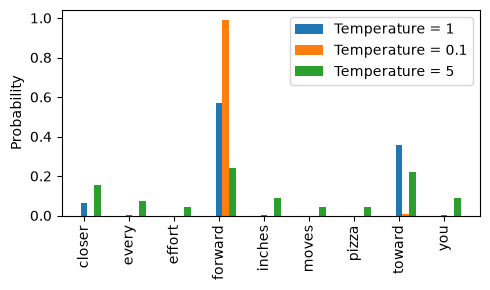

In [19]:
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

A temperature of 1 divides the logits by 1 before passing them to the softmax function to compute the probability scores.

In other words, using a temperature of 1 is the same as not using any temperature scaling.

In this case, the tokens are selected with a probability equal to the original softmax probability scores via the multinomial sampling function in PyTorch.

Applying very small temperatures, such as 0.1, will result in sharper distributions such that the behavior of the multinomial function selects the most likely token (here: "forward") almost 100% of the time, approaching the behavior of the argmax function.

Vice versa, a temperature of 5 results in a more uniform distribution where other tokens are selected more often.

This can add more variety to the generated texts but also more often results in nonsensical text.

For example, using the temperature of 5 results in texts such as "every effort moves you pizza" about 4% of the time.

## **DECODING STRATEGY 2: TOP-K SAMPLING**

In the previous section, we implemented a probabilistic sampling approach coupled with temperature scaling to increase the diversity of the outputs.

We saw that higher temperature values result in more uniformly distributed next-token probabilities, which result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting the most probable token.

This method allows for exploring less likely but potentially more interesting and creative paths in the generation process.

However, One downside of this approach is that it sometimes leads to grammatically incorrect or completely nonsensical outputs such as "every effort moves you pizza".

In this section, we introduce another concept called top-k sampling, which, when combined with probabilistic sampling and temperature scaling, can improve the text generation results.

In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens and exclude all other tokens from the selection process by masking their probability scores.

In [20]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


Subsequently, we apply PyTorch's where function to set the logit values of tokens that are below the lowest logit value within our top-3 selection to negative infinity (-inf).

In [21]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


Lastly, let's apply the softmax function to turn these into next-token probabilities:

In [22]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Merge Temperature Scaling and Top-k sampling

We can now apply the temperature scaling and multinomial function for probabilistic sampling introduced in the previous section to select the next token among these 3 nonzero probability scores to generate the next token. We do this in the next section by modifying the text generation function.

The previous two subsections introduced two concepts to increase the diversity of LLMgenerated text: temperature sampling and top-k sampling. In this section, we combine and add these concepts to modify the generate_simple function we used to generate text via the LLM earlier, creating a new generate function:

Step 1: For-loop is the same as before: Get logits, and only focus on last time step

Step 2: In this new section, we filter logits with top_k sampling

Step 3: This is the new section where we apply temperature scaling

Step 4: Carry out greedy next-token selection as before when temperature scaling is disabled

Step 5: Stop generating early if end-of-sequence token is encountered and eos_id is specified

In [23]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

Let's now see this new generate function in action:

In [24]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you inferred rolleduint fabricationagos remarkably hereuced saints freewaylookOkayRand salary baseless


As we can see, the generated text is very different from the one we previously generated via the generate_simple function at the beginning of section 5.3 ("Every effort moves you know," was one of the axioms he laid...!"), which was a memorized passage from the training set.

# **LOADING AND SAVING MODEL WEIGHTS IN PYTORCH**

Fortunately, saving a PyTorch model is relatively straightforward.

The recommended way is to save a model's so-called state_dict, a dictionary mapping each layer to its parameters, using the torch.save function as follows:

In [25]:
model = GPTModel(GPT_CONFIG_124M)
torch.save(model.state_dict(), "model.pth")

In the preceding code, "model.pth" is the filename where the state_dict is saved.

The .pth extension is a convention for PyTorch files, though we could technically use any file extension.

Then, after saving the model weights via the state_dict, we can load the model weights into a new GPTModel model instance as follows:

In [26]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth"))
model.eval()

C:\Temp\ipykernel_1244\2695484513.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("model.pth"))


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

If we plan to continue pretraining a model later, for example, using the train_model_simple function we defined earlier in this chapter, saving the optimizer state is also recommended.

Adaptive optimizers such as AdamW store additional parameters for each model weight. AdamW uses historical data to adjust learning rates for each model parameter dynamically.

Without it, the optimizer resets, and the model may learn suboptimally or even fail to converge properly, which means that it will lose the ability to generate coherent text.

Using torch.save, we can save both the model and optimizer state_dict contents as follows:

In [27]:
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    }, 
    "model_and_optimizer.pth"
)

Then, we can restore the model and optimizer states as follows by first loading the saved data via torch.load and then using the load_state_dict method:

In [28]:
checkpoint = torch.load("model_and_optimizer.pth")
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

C:\Temp\ipykernel_1244\2526848825.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("model_and_optimizer.pth")


# **LOADING PRETRAINED WEIGHTS FROM OPENAI**

Previously, for educational purposes, we trained a small GPT-2 model using a limited dataset comprising a short-story book.

This approach allowed us to focus on the fundamentals without the need for extensive time and computational resources.

Fortunately, OpenAI openly shared the weights of their GPT-2 models, thus eliminating the need to invest tens to hundreds of thousands of dollars in retraining the model on a large corpus ourselves.

In the remainder of this section, we load these weights into our GPTModel class and use the model for text generation.

Here, weights refer to the weight parameters that are stored in the .weight attributes of PyTorch's Linear and Embedding layers, for example.

We accessed them earlier via model.parameters() when training the model.

Note that OpenAI originally saved the GPT-2 weights via TensorFlow, which we have to install to load the weights in Python.

Moreover, the following code will use a progress bar tool called tqdm to track the download process, which we also have to install.

In [29]:
import platform
print("Processor:", platform.processor())
print("Machine:", platform.machine())

Processor: Intel64 Family 6 Model 158 Stepping 10, GenuineIntel
Machine: AMD64


In [30]:
import cpuinfo
info = cpuinfo.get_cpu_info()
print("CPU Name:", info.get('brand_raw'))
print("AVX available:", 'avx' in info.get('flags', []))
print("AVX2 available:", 'avx2' in info.get('flags', []))

CPU Name: Intel(R) Core(TM) i5-9300H CPU @ 2.40GHz
AVX available: True
AVX2 available: True


In [31]:
import tensorflow as tf
import tqdm

print("TensorFlow version:", tf.__version__)
print("tqdm version:", tqdm.__version__)

TensorFlow version: 2.21.0
tqdm version: 4.70.0


We download the gpt_download.py Python module directly from this chapter's online repository

We can now import the download_and_load_gpt2 function from the gpt_download.py file as follows, which will load the GPT-2 architecture settings (settings) and weight parameters (params) into our Python session:

In [32]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch05/01_main-chapter-code/gpt_download.py"
filename = url.split('/')[-1]

urllib.request.urlretrieve(url, filename)
print(f"Downloaded {filename} successfully!")

Downloaded gpt_download.py successfully!


In [33]:
from gpt_download import download_and_load_gpt2

We download the gpt_download.py Python module directly from this chapter's online repository

We can now import the download_and_load_gpt2 function from the gpt_download.py file as follows, which will load the GPT-2 architecture settings (settings) and weight parameters (params) into our Python session:

In [34]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


After the execution of the previous code has been completed, let's inspect the contents of settings and params:

In [35]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


Both settings and params are Python dictionaries. The settings dictionary stores the LLM architecture settings similarly to our manually defined GPT_CONFIG_124M settings.

The params dictionary contains the actual weight tensors.

Note that we only printed the dictionary keys because printing the weight contents would take up too much screen space

We can inspect these weight tensors by printing the whole dictionary via print(params) or by selecting individual tensors via the respective dictionary keys, for example, the embedding layer weights:

In [36]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


We downloaded and loaded the weights of the smallest GPT-2 model via the download_and_load_gpt2(model_size="124M", ...) setting. However, note that OpenAI also shares the weights of larger models: "355M", "774M", and "1558M".

Above, we loaded the 124M GPT-2 model weights into Python, however we still need to transfer them into our GPTModel instance.

First, we initialize a new GPTModel instance.

Note that the original GPT model initialized the linear layers for the query, key, and value matrices in the multi-head attention module with bias vectors, which is not required or recommended; however, to be able to load the weights correctly, we have to enable these too by setting qkv_bias to True in our implementation, too.

We are also using the 1024 token context length that was used by the original GPT-2 model(s)

In [37]:
# Define model configurations in a dictionary for compactness
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

# Copy the base configuration and update with specific model settings
model_name = "gpt2-small (124M)"  # Example model name
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])


Careful readers may remember that we used a 256-token length earlier, but the original GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to update the NEW_CONFIG accordingly:

Also, OpenAI used bias vectors in the multi-head attention module's linear layers to implement the query, key, and value matrix computations.

Bias vectors are not commonly used in LLMs anymore as they don't improve the modeling performance and are thus unnecessary.

However, since we are working with pretrained weights, we need to match the settings for consistency and enable these bias vectors:

In [38]:
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})
gpt = GPTModel(NEW_CONFIG)
gpt.eval();

By default, the GPTModel instance is initialized with random weights for pretraining.

The last step to using OpenAI's model weights is to override these random weights with the weights we loaded into the params dictionary.

For this, we will first define a small assign utility function that checks whether two tensors or arrays (left and right) have the same dimensions or shape and returns the right tensor as trainable PyTorch parameters:

In [39]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(torch.tensor(right))

Next, we define a load_weights_into_gpt function that loads the weights from the params dictionary into a GPTModel instance gpt:

Step 1: Setting the model's positional and token embedding weights to those specified in params.

Step 2: Iterate over each transformer block in the model.

Step 3: The np.split function is used to divide the attention and bias weights into three equal parts for the query, key, and value components.

Step 4: The original GPT-2 model by OpenAI reused the token embedding weights in the output layer to reduce the total number of parameters, which is a concept known as weight tying.

In [40]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])
    
    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight, 
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias, 
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight, 
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias, 
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight, 
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias, 
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale, 
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift, 
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale, 
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift, 
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])



In the load_weights_into_gpt function, we carefully match the weights from OpenAI's implementation with our GPTModel implementation.

To pick a specific example, OpenAI stored the weight tensor for the output projection layer for the first transformer block as params["blocks"][0]["attn"]["c_proj"]["w"].

In our implementation, this weight tensor corresponds to gpt.trf_blocks[b].att.out_proj.weight, where gpt is a GPTModel instance.

Developing the load_weights_into_gpt function took a lot of guesswork since OpenAI used a slightly different naming convention from ours.

However, the assign function would alert us if we try to match two tensors with different dimensions.

Also, if we made a mistake in this function, we would notice this as the resulting GPT model would be unable to produce coherent text.

Let's now try the load_weights_into_gpt out in practice and load the OpenAI model weights into our GPTModel instance gpt:

In [41]:
load_weights_into_gpt(gpt, params)
gpt.to(device);

If the model is loaded correctly, we can now use it to generate new text using our previous generate function:

In [42]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn. By now there's a very small delay before you gain


We can be confident that we loaded the model weights correctly because the model can produce coherent text.

A tiny mistake in this process would cause the model to fail.

In the following chapters, we will work further with this pretrained model and fine-tune it to classify text and follow instructions.